In [ ]:
# ── Parameters (injected by papermill) ─────────────────
# Defaults for manual runs. The Flask backend overrides these via papermill -p.
CSV_PATH     = "../General-OSM-Scraper/csv/combined_2026-05-04_22-49-58.csv"
PLOTS_DIR    = "outputs/default"
EXCLUDE_COLS = "median_income,lanes"   # comma-separated columns to drop before EDA

# Data and libraries

In [4]:
# standard packaging
import matplotlib
matplotlib.use("Agg")  # non-interactive backend for headless/papermill runs

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True, rc={"figure.figsize":(10,8)})

from IPython.display import HTML

In [7]:
import os
NYC_spots = pd.read_csv(CSV_PATH)
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Loaded {len(NYC_spots)} rows from {CSV_PATH}")
print(NYC_spots.head())

             location       osm_id                       name        lat  \
0        times_square    796338420                        NaN  40.758949   
1        times_square    258619240                       TKTS  40.759153   
2        times_square   2613887631  American Eagle Outfitters  40.758865   
3        times_square   3595084281        Grand Slam New York  40.759125   
4        times_square   1740694091                 McDonald's  40.758775   
...               ...          ...                        ...        ...   
8770  lower_east_side   4202805400                 McDonald's  40.729100   
8771  lower_east_side   2547121455            Abacus Pharmacy  40.730093   
8772  lower_east_side   2897876739                     Souths  40.718452   
8773  lower_east_side  12322546580       Queens Beauty Parlor  40.729566   
8774  lower_east_side    250052719                 Roxy Hotel  40.719371   

            lon          label  distance_m  lot_area_sqft highway_type  lanes  \
0    -

In [8]:
print(NYC_spots["label"].value_counts())

label
food_drink               3999
retail                   2289
personal_care             785
leisure_entertainment     528
health                    413
finance                   303
hospitality               272
office_professional       186
Name: count, dtype: int64


In [14]:
#inspect data
NYC_spots.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8775 entries, 0 to 8774
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   location         8775 non-null   object 
 1   osm_id           8775 non-null   int64  
 2   name             8528 non-null   object 
 3   lat              8775 non-null   float64
 4   lon              8775 non-null   float64
 5   label            8775 non-null   object 
 6   distance_m       8775 non-null   float64
 7   lot_area_sqft    8768 non-null   float64
 8   highway_type     8775 non-null   object 
 9   lanes            6814 non-null   float64
 10  dist_bus_stop_m  8775 non-null   float64
 11  dist_hospital_m  8775 non-null   float64
 12  dist_school_m    8775 non-null   float64
 13  dist_park_m      8775 non-null   float64
 14  res_ratio        8379 non-null   float64
 15  com_ratio        8379 non-null   float64
 16  median_income    0 non-null      float64
dtypes: float64(12)

In [17]:
print(f"Total rows: {len(NYC_spots)}")
print("\nNull counts per column:")
print(NYC_spots.isnull().sum())

Total rows: 8775

Null counts per column:
location              0
osm_id                0
name                247
lat                   0
lon                   0
label                 0
distance_m            0
lot_area_sqft         7
highway_type          0
lanes              1961
dist_bus_stop_m       0
dist_hospital_m       0
dist_school_m         0
dist_park_m           0
res_ratio           396
com_ratio           396
median_income      8775
dtype: int64


## Drop rows with any null values

In [24]:
_exclude = [c.strip() for c in EXCLUDE_COLS.split(",") if c.strip() in NYC_spots.columns]
NYC_clean = NYC_spots.drop(columns=_exclude) if _exclude else NYC_spots.copy()
NYC_clean = NYC_clean.dropna()
print(f"Dropped columns: {_exclude}")
print(f"Rows remaining: {len(NYC_clean)}")
print("\nNull counts after cleaning:")
print(NYC_clean.isnull().sum())

Rows remaining: 8153

Null counts after cleaning:
location           0
osm_id             0
name               0
lat                0
lon                0
label              0
distance_m         0
lot_area_sqft      0
highway_type       0
dist_bus_stop_m    0
dist_hospital_m    0
dist_school_m      0
dist_park_m        0
res_ratio          0
com_ratio          0
dtype: int64


In [25]:
NYC_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8153 entries, 1 to 8774
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   location         8153 non-null   object 
 1   osm_id           8153 non-null   int64  
 2   name             8153 non-null   object 
 3   lat              8153 non-null   float64
 4   lon              8153 non-null   float64
 5   label            8153 non-null   object 
 6   distance_m       8153 non-null   float64
 7   lot_area_sqft    8153 non-null   float64
 8   highway_type     8153 non-null   object 
 9   dist_bus_stop_m  8153 non-null   float64
 10  dist_hospital_m  8153 non-null   float64
 11  dist_school_m    8153 non-null   float64
 12  dist_park_m      8153 non-null   float64
 13  res_ratio        8153 non-null   float64
 14  com_ratio        8153 non-null   float64
dtypes: float64(10), int64(1), object(4)
memory usage: 1019.1+ KB


In [26]:
print(NYC_clean.groupby(["location", "label"]).size().unstack(fill_value=0))

label            finance  food_drink  health  hospitality  \
location                                                    
harlem                32         314      53            4   
lower_east_side       59        1499     118           40   
times_square         106        1290      84          111   
upper_east_side       59         693     137           10   

label            leisure_entertainment  office_professional  personal_care  \
location                                                                     
harlem                              36                   16             56   
lower_east_side                    232                   45            308   
times_square                       166                  101            110   
upper_east_side                     64                   14            268   

label            retail  
location                 
harlem              153  
lower_east_side     918  
times_square        636  
upper_east_side     421  


In [27]:
print(NYC_clean["label"].value_counts())

label
food_drink               3796
retail                   2128
personal_care             742
leisure_entertainment     498
health                    392
finance                   256
office_professional       176
hospitality               165
Name: count, dtype: int64


In [31]:
print(NYC_clean["label"].unique())
print(NYC_clean["res_ratio"].unique())


['retail' 'food_drink' 'leisure_entertainment' 'hospitality' 'health'
 'personal_care' 'finance' 'office_professional']
[0.         0.6        0.2        ... 0.93333742 0.25644313 0.92994396]


Exploratory Data Analysis (EDA)



In [ ]:
print(NYC_clean["label"].value_counts())

label
food_drink               1184
retail                    596
leisure_entertainment     154
personal_care             111
finance                   106
hospitality               103
office_professional        90
health                     78
Name: count, dtype: int64


because of the huge gap i'm taking a sample of 78 data point from each label to check if a pattern exist

In [37]:
spots = sorted(NYC_clean["location"].unique().tolist())
print("Locations found:", spots)

for spot in spots:
    spot_df = NYC_clean[NYC_clean["location"] == spot]
    min_class = spot_df["label"].value_counts().min()
    sample = pd.concat([
        grp.sample(min(len(grp), min_class), random_state=11)
        for _, grp in spot_df.groupby("label")
    ]).reset_index(drop=True)
    print("\n=== " + spot + " ===")
    sample.info()
    print(sample["label"].value_counts())


=== times_square ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   location         672 non-null    object 
 1   osm_id           672 non-null    int64  
 2   name             672 non-null    object 
 3   lat              672 non-null    float64
 4   lon              672 non-null    float64
 5   label            672 non-null    object 
 6   distance_m       672 non-null    float64
 7   lot_area_sqft    672 non-null    float64
 8   highway_type     672 non-null    object 
 9   dist_bus_stop_m  672 non-null    float64
 10  dist_hospital_m  672 non-null    float64
 11  dist_school_m    672 non-null    float64
 12  dist_park_m      672 non-null    float64
 13  res_ratio        672 non-null    float64
 14  com_ratio        672 non-null    float64
dtypes: float64(10), int64(1), object(4)
memory usage: 78.9+ KB
label
finance              

/tmp/ipykernel_1630/19440156.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = spot_df.groupby("label").apply(
/tmp/ipykernel_1630/19440156.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = spot_df.groupby("label").apply(
/tmp/ipykernel_1630/19440156.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version o

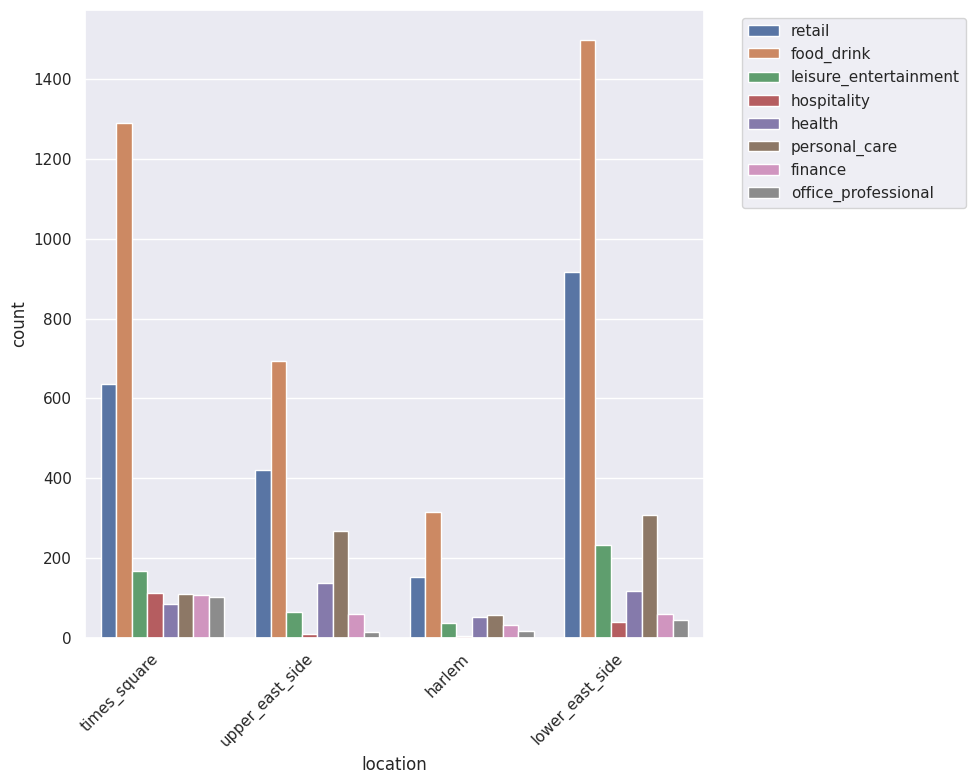

In [39]:
sns.countplot(x="location", hue="label", data=NYC_clean)
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/01_countplot_location_label.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 1600x600 with 0 Axes>

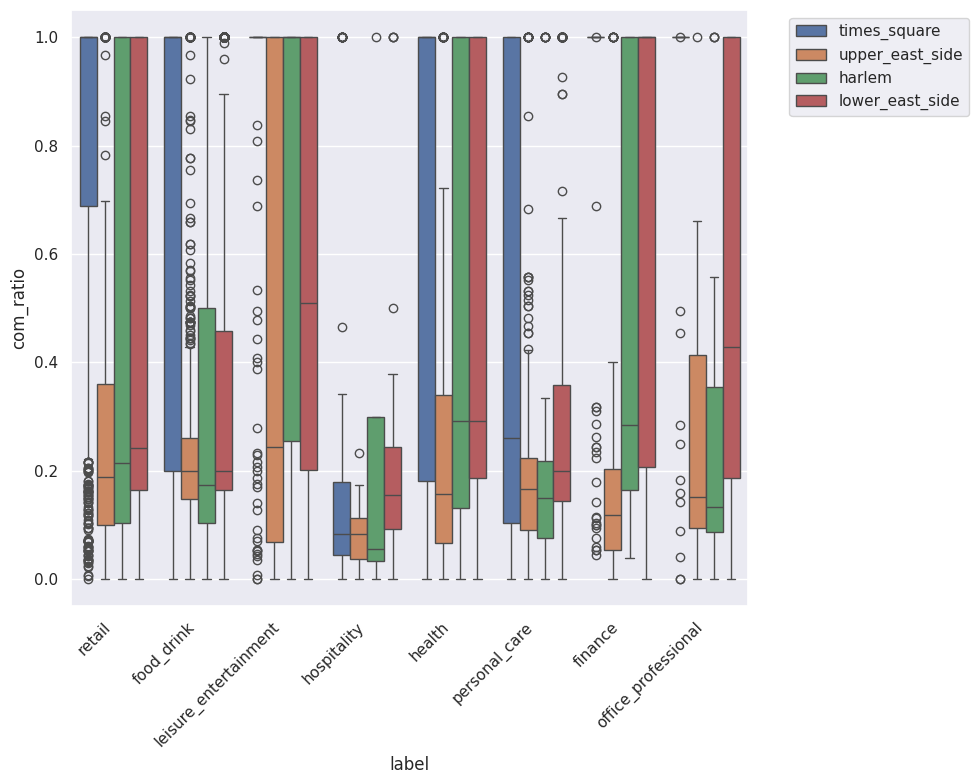

<Figure size 1600x600 with 0 Axes>

In [41]:
if "com_ratio" in NYC_clean.columns:
    plt.figure(figsize=(16, 6))
    sns.boxplot(x="label", y="com_ratio", hue="location", data=NYC_clean)
    plt.xticks(rotation=45, ha="right")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/02_boxplot_com_ratio.png", dpi=150, bbox_inches="tight")
    plt.show()

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'retail'),
  Text(1, 0, 'food_drink'),
  Text(2, 0, 'leisure_entertainment'),
  Text(3, 0, 'hospitality'),
  Text(4, 0, 'health'),
  Text(5, 0, 'personal_care'),
  Text(6, 0, 'finance'),
  Text(7, 0, 'office_professional')])

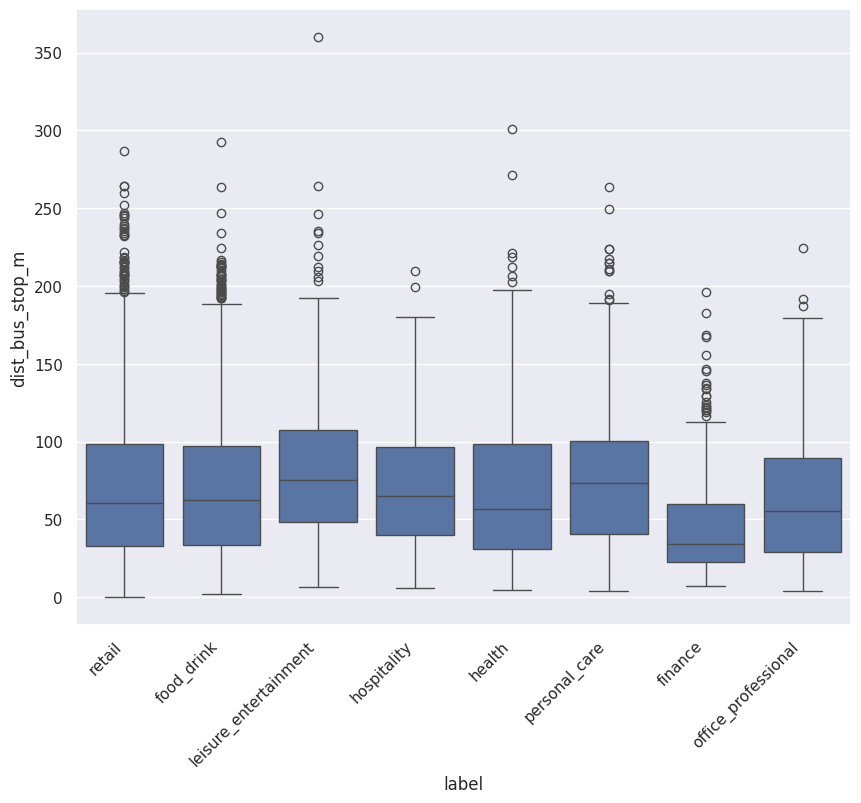

In [45]:
if "dist_hospital_m" in NYC_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="label", y="dist_hospital_m", data=NYC_clean)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/03_boxplot_dist_hospital.png", dpi=150, bbox_inches="tight")
    plt.show()

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'finance'),
  Text(1, 0, 'food_drink'),
  Text(2, 0, 'health'),
  Text(3, 0, 'hospitality'),
  Text(4, 0, 'leisure_entertainment'),
  Text(5, 0, 'office_professional'),
  Text(6, 0, 'personal_care'),
  Text(7, 0, 'retail')])

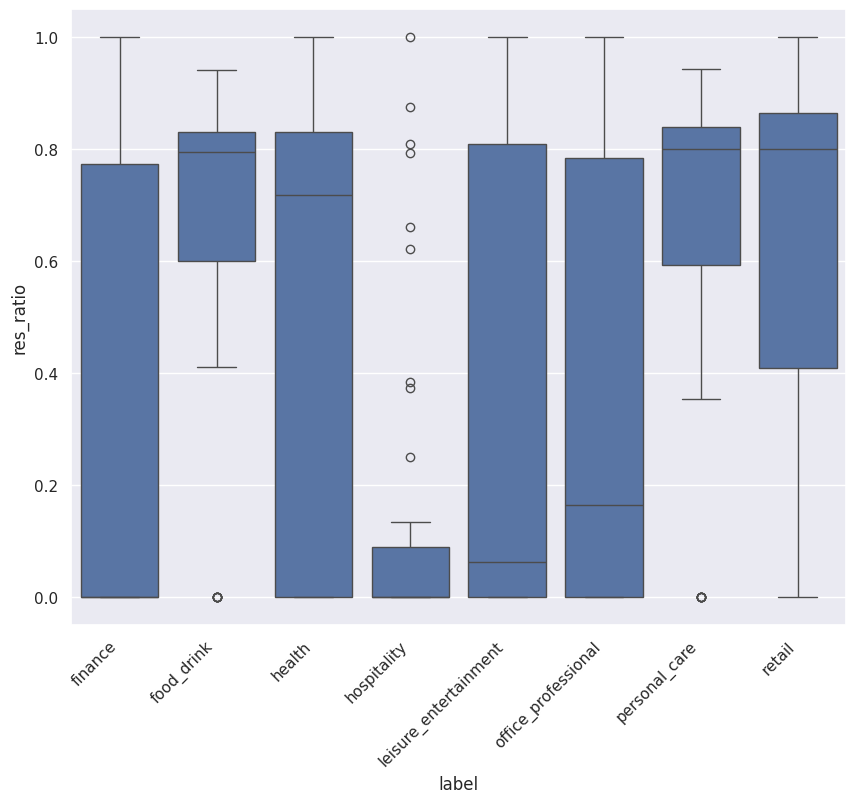

In [47]:
if "res_ratio" in NYC_clean.columns:
    _min_c = NYC_clean["label"].value_counts().min()
    sample = pd.concat([
        grp.sample(min(len(grp), _min_c), random_state=11)
        for _, grp in NYC_clean.groupby("label")
    ]).reset_index(drop=True)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="label", y="res_ratio", data=sample)
    plt.ylabel("res_ratio")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/04_boxplot_res_ratio.png", dpi=150, bbox_inches="tight")
    plt.show()

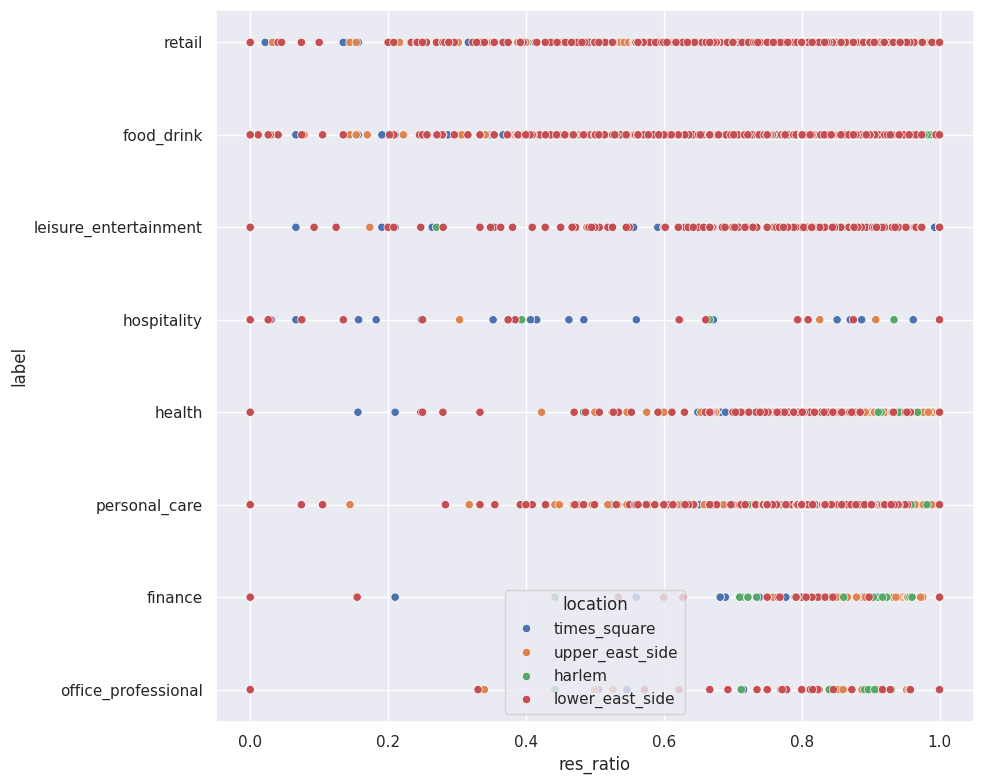

In [60]:
if "res_ratio" in NYC_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x="res_ratio", y="label", hue="location", data=NYC_clean)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/05_scatter_res_ratio.png", dpi=150, bbox_inches="tight")
    plt.show()

In [58]:
_eda_cols = ["lot_area_sqft", "dist_bus_stop_m", "dist_hospital_m", "dist_school_m",
             "dist_park_m", "com_ratio", "res_ratio"]
numeric_cols = [c for c in _eda_cols if c in NYC_clean.columns]

for spot in spots:
    spot_df = NYC_clean[NYC_clean["location"] == spot]
    if len(spot_df) < 4:
        continue
    _min = spot_df["label"].value_counts().min()
    _s = pd.concat([
        grp.sample(min(len(grp), _min), random_state=11)
        for _, grp in spot_df.groupby("label")
    ]).reset_index(drop=True)
    sns.pairplot(_s[numeric_cols + ["label"]], hue="label")
    plt.suptitle(spot, y=1.02)
    plt.savefig(f"{PLOTS_DIR}/06_pairplot_{spot}.png", dpi=100, bbox_inches="tight")
    plt.show()

_min_all = NYC_clean["label"].value_counts().min()
_s_all = pd.concat([
    grp.sample(min(len(grp), _min_all), random_state=11)
    for _, grp in NYC_clean.groupby("label")
]).reset_index(drop=True)
sns.pairplot(_s_all[numeric_cols + ["label"]], hue="label")
plt.suptitle("All Spots Combined", y=1.02)
plt.savefig(f"{PLOTS_DIR}/07_pairplot_combined.png", dpi=100, bbox_inches="tight")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Text(0.5, 1.0, 'Feature Correlation Heatmap')

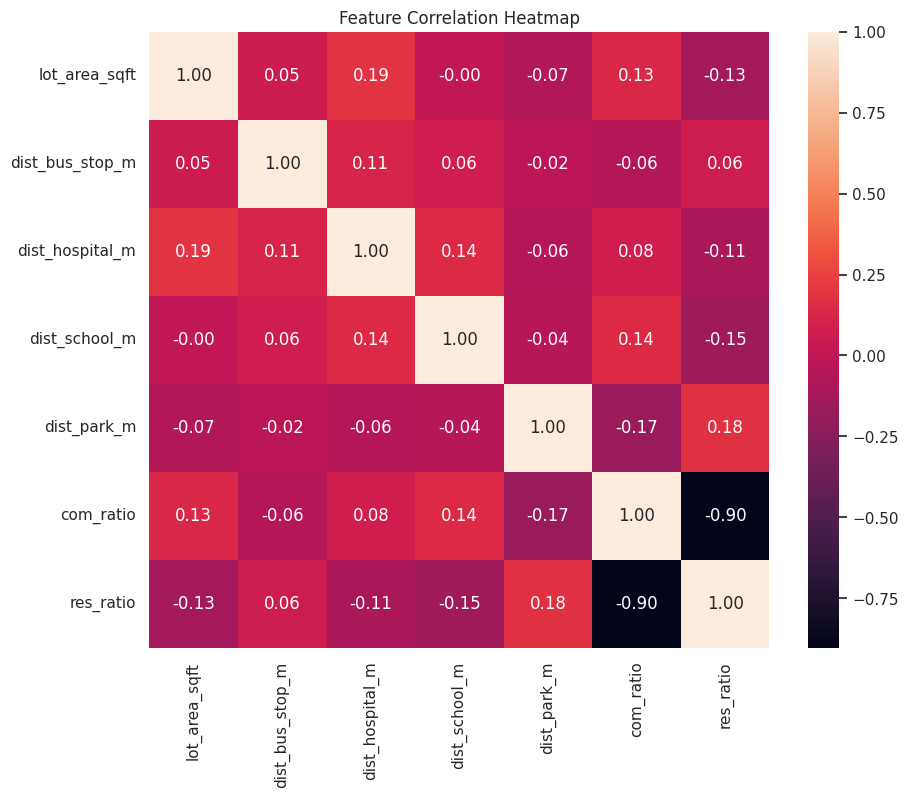

In [59]:
_eda_cols = ["lot_area_sqft", "dist_bus_stop_m", "dist_hospital_m", "dist_school_m",
             "dist_park_m", "com_ratio", "res_ratio"]
numeric_cols = [c for c in _eda_cols if c in NYC_clean.columns]
NYC_num = NYC_clean[numeric_cols]
plt.figure(figsize=(10, 8))
sns.heatmap(NYC_num.corr(), annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/08_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [66]:
_always_drop = ["com_ratio", "distance_m", "location", "osm_id",
                "name", "lat", "lon", "lot_area_log"]
_to_drop = [c for c in _always_drop if c in NYC_clean.columns]
NYC_model = NYC_clean.drop(columns=_to_drop)
print(NYC_model.columns.tolist())
print(f"Shape: {NYC_model.shape}")

['label', 'lot_area_sqft', 'highway_type', 'dist_bus_stop_m', 'dist_hospital_m', 'dist_school_m', 'dist_park_m', 'res_ratio']
Shape: (8153, 8)


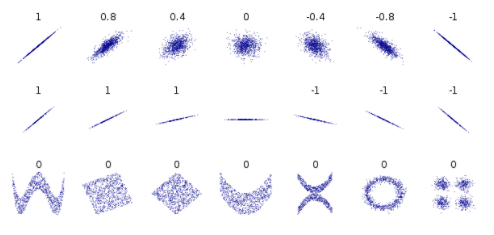

Adelie has smaller culmen length than the other two species
Gentoo has larger flipper length than the other two species
Gentoo are also heavier than the other two species
Adelie are the only penguins living on the three islands, chinstrap only on Dream and Gentoo only on Biscoe

Flipper length and body mass  positevly correlated length features > bigger animal, need for stronger flippers and larger beak to eat more

# Data Inspection

#Data prep

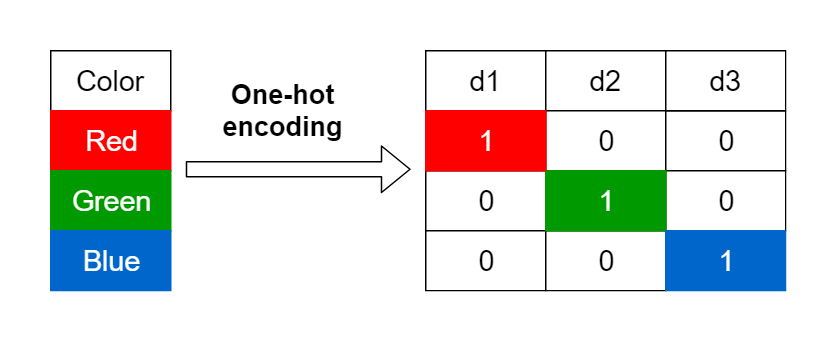

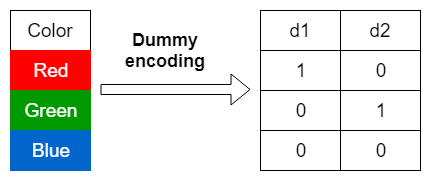

encoding

In [67]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

NYC_model["highway_type"] = encoder.fit_transform(NYC_model["highway_type"])
NYC_model["label"] = encoder.fit_transform(NYC_model["label"])
NYC_model

,label,lot_area_sqft,highway_type,dist_bus_stop_m,dist_hospital_m,dist_school_m,dist_park_m,res_ratio
1,7,3324.0,5,41.7,420.4,345.6,41.6,0.000000
2,7,4350.0,6,98.9,428.0,322.1,31.3,0.000000
3,7,5200.0,6,76.0,442.3,332.8,45.0,0.000000
4,1,3234.0,6,70.4,376.7,302.4,35.9,0.000000
5,7,4350.0,6,99.4,430.6,324.3,33.8,0.000000
...,...,...,...,...,...,...,...,...
8770,1,3648.0,3,32.5,55.4,170.9,167.4,0.000000
8771,2,7616.0,3,129.5,143.7,150.8,64.2,0.933337
8772,1,1884.0,5,152.1,301.8,173.6,33.9,0.256443
8773,6,2575.0,6,99.1,180.9,118.2,117.8,0.929944


In [68]:
import numpy as np

numeric_cols = ['lot_area_sqft', 'highway_type', 'dist_bus_stop_m', 'dist_hospital_m', 'dist_school_m', 'dist_park_m', 'res_ratio']

for col in numeric_cols:
    print(f"{col}: min={NYC_model[col].min():.1f}, max={NYC_model[col].max():.1f}, mean={NYC_model[col].mean():.1f}, median={NYC_model[col].median():.1f}")

lot_area_sqft: min=216.0, max=4227757.0, mean=16323.0, median=3750.0
highway_type: min=0.0, max=11.0, mean=4.9, median=5.0
dist_bus_stop_m: min=0.0, max=359.8, mean=70.7, median=62.3
dist_hospital_m: min=0.0, max=949.9, mean=217.5, median=199.7
dist_school_m: min=4.4, max=582.8, mean=192.5, median=173.5
dist_park_m: min=0.5, max=758.2, mean=165.0, median=132.9
res_ratio: min=0.0, max=1.0, mean=0.5, median=0.7


scaling

In [69]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [70]:
X = NYC_model.drop(columns=["label"])
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.16446556,  0.04710781, -0.63089658, ...,  1.48694615,
        -0.97095535, -1.24125519],
       [-0.15148445,  0.83092403,  0.61503496, ...,  1.25866769,
        -1.05202406, -1.24125519],
       [-0.14073012,  0.83092403,  0.1162267 , ...,  1.36260724,
        -0.94419481, -1.24125519],
       ...,
       [-0.18268466,  0.04710781,  1.77383842, ..., -0.18385796,
        -1.03156011, -0.59461001],
       [-0.17394202,  0.83092403,  0.61939136, ..., -0.72201231,
        -0.37120431,  1.10368487],
       [-0.03583113,  0.04710781,  0.50830306, ...,  0.70691377,
        -1.18740094, -1.24125519]])

In [71]:
import numpy as np
y = np.asarray(NYC_model["label"])
y

array([7, 7, 7, ..., 1, 6, 3])

splitting

In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)


(6522, 7)
(6522,)
(1631, 7)


#Train model

In [73]:
# Import K-fold crossvalidation
from sklearn.model_selection import cross_val_score

# Import Classification Report for later evaluatoion of performance
from sklearn.metrics import classification_report

Logistic Regression

In [74]:
# Import and instantiate the model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000, class_weight="balanced")

# K-fold cross-validation (splitting the 80% into 5 chunks, using 4 to train and 1 to evaluate)
scores = cross_val_score(model, X_train, y_train, cv = 5)
print(scores)



[0.13256705 0.15019157 0.14417178 0.14187117 0.14263804]


In [75]:
# Model training
model.fit(X_train, y_train)

# Model performance on the test-set
print(model.score(X_test, y_test))

0.15511955855303494


# skip

In [ ]:
target_names_penguins = encoder.inverse_transform(list(set(y_test)))
y_pred = model.predict(X_test)


In [ ]:
print(target_names_penguins)


['Adelie' 'Chinstrap' 'Gentoo']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 48.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have 

(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

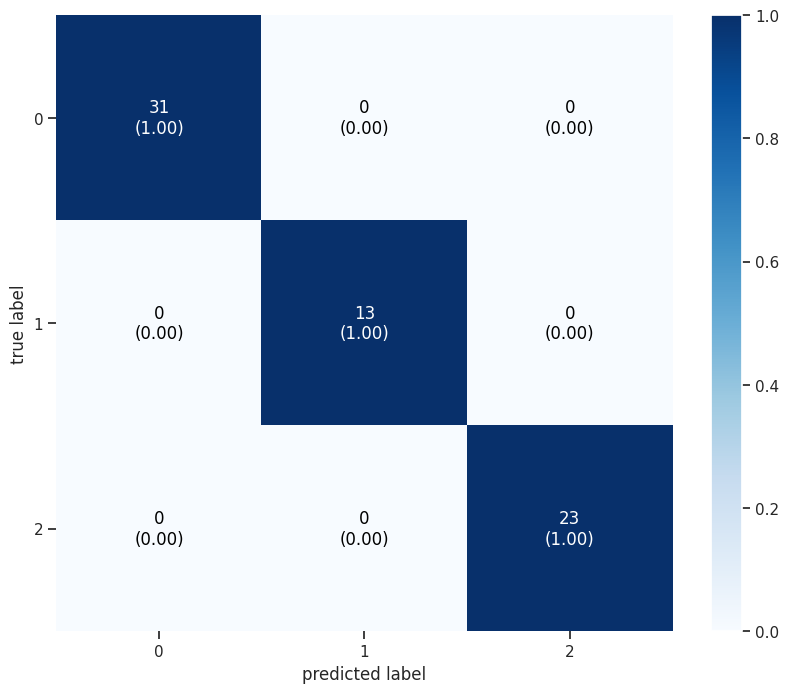

In [ ]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

confmatrix = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(conf_mat=confmatrix, colorbar=True,
                      show_absolute=True, show_normed=True, hide_spines=True)
plt.title("Logistic Regression — Confusion Matrix")
plt.savefig(f"{PLOTS_DIR}/09_confusion_matrix_lr.png", dpi=150, bbox_inches="tight")
plt.show()

# XG boost

In [76]:
import xgboost as xgb

model = xgb.XGBClassifier(random_state=14)

scores = cross_val_score(model, X_train, y_train, cv = 5)
print(scores)

model.fit(X_train, y_train)
print(model.score(X_test, y_test))

[0.44904215 0.46896552 0.49769939 0.46472393 0.47392638]
0.483752299202943


In [77]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.29      0.11      0.16        54
           1       0.52      0.78      0.62       765
           2       0.65      0.24      0.35        82
           3       0.00      0.00      0.00        31
           4       0.21      0.07      0.10        88
           5       0.24      0.11      0.15        35
           6       0.30      0.10      0.15       142
           7       0.43      0.33      0.37       434

    accuracy                           0.48      1631
   macro avg       0.33      0.22      0.24      1631
weighted avg       0.44      0.48      0.44      1631



In [78]:
# Performance evaluation using the classification_report
y_pred = model.predict(X_test) # predict from the testset


In [79]:
confmatrix = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(conf_mat=confmatrix, colorbar=True,
                      show_absolute=True, show_normed=True)
plt.title("XGBoost — Confusion Matrix")
plt.savefig(f"{PLOTS_DIR}/10_confusion_matrix_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'confusion_matrix' is not defined

## Random forest

In [80]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(class_weight="balanced", random_state=42)

scores = cross_val_score(model_rf, X_train, y_train, cv=5)
print(f"Cross-val scores: {scores}")
print(f"Mean: {scores.mean():.3f}")

model_rf.fit(X_train, y_train)
print(f"\nTest accuracy: {model_rf.score(X_test, y_test):.3f}")

Cross-val scores: [0.4697318  0.45823755 0.49846626 0.47546012 0.49079755]
Mean: 0.479

Test accuracy: 0.484


In [81]:
from sklearn.metrics import classification_report

y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.44      0.15      0.22        54
           1       0.52      0.76      0.62       765
           2       0.64      0.30      0.41        82
           3       0.00      0.00      0.00        31
           4       0.26      0.07      0.11        88
           5       0.27      0.09      0.13        35
           6       0.31      0.13      0.19       142
           7       0.42      0.33      0.37       434

    accuracy                           0.48      1631
   macro avg       0.36      0.23      0.26      1631
weighted avg       0.45      0.48      0.44      1631

